# Piplie For Reachability Analysis of Duffing Oscillator (Nonlienar) Under A Fix Contorl Law

Reachability of an autonomous closed-loop nonlinear system

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from scipy.linalg import solve_discrete_are
from pykoopman import observables, regression
import pykoopman as pk
from KRTB_pyKoopman import KoopmanModelTrainer, KoopmanAnalysis, integralRK4
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

**Load configs and define the system**

In [2]:
np.random.seed(5)

curdir = os.path.dirname("duffing_KRTB_FixedController.ipynb")
config_path = os.path.join(curdir, "configs", "controlled_duffing.json")
stream = print

kmt = KoopmanModelTrainer(config_path, curdir, save_model=True, save_sim_data=True, stream=stream)

## Phase A: Learn system dynamic with open-loop data

In [3]:
def genRandControlCmd(n_sample, t_vec): 
    amp = np.random.uniform(-1, 1, size=n_sample) 
    f = 0.5 # signal frequency (Hz) 
    U = np.outer(amp, (np.sin(2 * np.pi * f * t_vec) >= 0)) 
    return np.expand_dims(U, axis=2)

**Generate open-loop simulated trajectories**

In [4]:
states_ol, controls_ol, t_vec = kmt.simTrajOpenLoop(genRandControlCmd)

Simulating trajectories ...
Simulation is Done!
Generating Simulated Trajectory to Train a Koopman Model
 Num. simulated trajectories: 5000
 Random seed: None
 State bounds: 
  x1: [-2, 2]
  x2: [-2, 2]

 Simulation time span (sec): 5.000 [0.000, 5.000] 
 Time step(sec): 0.01 
 Process runtime (sec): 0.851
 Simulated trajectories are stored at: sim_trajectories/duffing.npz


#### Plot Random open-loop simulated trajectories for demonstration

[-1.67703492 -1.09172759]


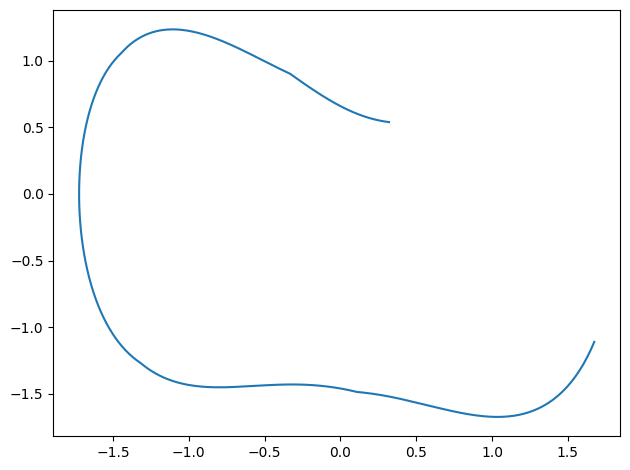

In [5]:
# rand_num = np.random.randint(0, 5000, 5)
rand_num = [3]
fig, ax = plt.subplots()
for i in rand_num:
    ax.plot(states_ol[i, :, 0], states_ol[i, :, 1])
print(states_ol[10, 0, :])

plt.tight_layout()
plt.show()

### Train open-loop EDMD with Control

**Define dectionary of observables**

In [6]:
centers = np.random.uniform(-1.5, 1.5, (2, 15))   # 20 centers
obs = observables.RadialBasisFunction(
    rbf_type="thinplate",
    n_centers=centers.shape[1],
    centers=centers,
    kernel_width=1.0,
    polyharmonic_coeff=1.0,
    include_state=True,
)

**Fit EDMDc**

In [7]:
reg = regression.EDMDc()
pk_edmdc = kmt.trainPyKoopmanModel(states_ol, controls=controls_ol, regressor=reg, observables=obs)

Training a pyKoopman Model based on Simulated Trajectories

 Process runtime (sec): 7.652900
 Trained model is stored at: sim_trajectories/duffing.npz


#### EDMDc trajectory simulation for demonstration

/home/ali/my_ws/Thesis/venv/lib/python3.10/site-packages/pykoopman/koopman.py:302: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


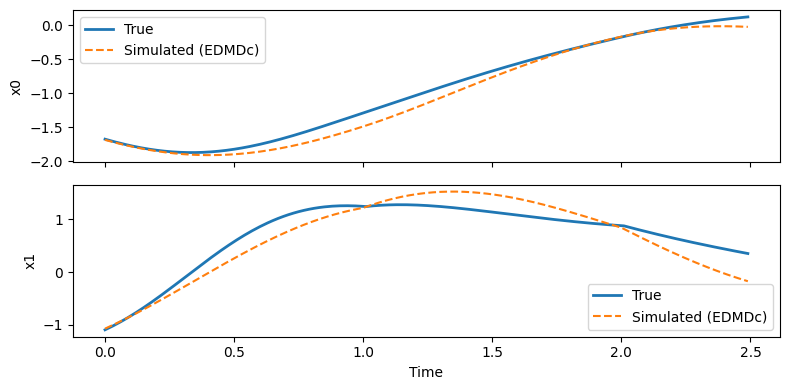

In [8]:
idx = 10
n_ss = 250

X_true = states_ol[idx, :n_ss]
traj_u = controls_ol[idx, :n_ss]
x0 = X_true[0]

X_sim = pk_edmdc.simulate(x0, traj_u, n_ss)

t = t_vec[:X_sim.shape[0]]
n_states = X_true.shape[1]
fig, axs = plt.subplots(n_states, 1, figsize=(8, 2*n_states), sharex=True)

for i in range(n_states):
    axs[i].plot(t, X_true[:, i], label="True", linewidth=2)
    axs[i].plot(t, X_sim[:, i], "--", label="Simulated (EDMDc)")
    axs[i].set_ylabel(f"x{i}")
    axs[i].legend()

axs[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

### Desing Koopman LQR Controller on lifted linear model

\begin{align}
z_{k+1} = A z_{k} + B \pi(x_{k}), \ \ \ with \ \ \ x_k = C z_k
\end{align}

In [9]:
def dlqr(A, B, Q, R):
    P = solve_discrete_are(A, B, Q, R)
    K = np.linalg.inv(B.T @ P @ B + R) @ (B.T @ P @ A)
    return K, P

def sat(u, umax):
    return np.clip(u, -umax, umax)

def koopman_lqr_u(x, K, pk_model, umax=1.0):
    x1e = -2.0
    x_eq = np.array([x1e, 0.0])
    u_eq = x1e**3 - x1e   # feedforward that makes x_eq an equilibrium
    
    z = pk_model.observables.transform(x)
    z_ref = pk_model.observables.transform(x_eq.reshape(1, -1))
    v = -K @ (z - z_ref).T  # feedback term
    u = v + u_eq # total = feedforward + feedback
    # return sat(u, umax).reshape(1, -1)
    return u

In [10]:
A = pk_edmdc.A
B = pk_edmdc.B
C = pk_edmdc.C
nz = A.shape[0]

Qx = np.diag([1, 10])
Q = C.T @ Qx @ C + 1e-6*np.eye(nz)
R = np.array([[3]]) # tune this

K, _ = dlqr(A, B, Q, R)

## Phase B: Learn closed-loop dynamic underf fixed policy $ u_k=\pi(x_k)\ $

#### How does the close-loop dynamic looks like with this policy?

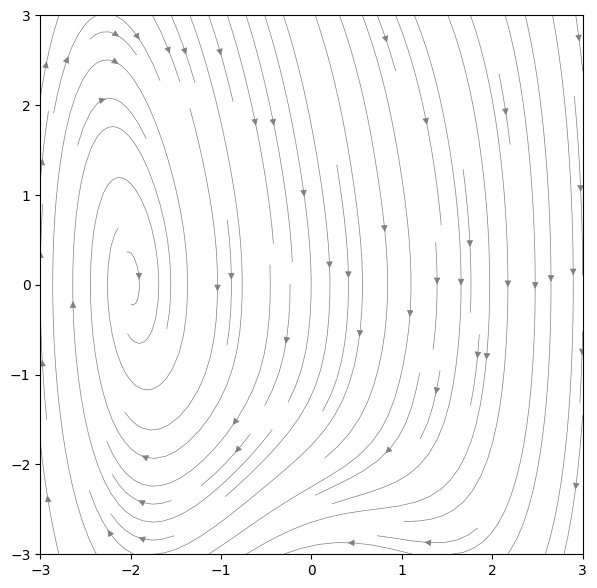

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))
x_lim = [-3, 3]
y_lim = [-3, 3]

grid_x = np.linspace(x_lim[0], x_lim[1], 30)
grid_y = np.linspace(y_lim[0], y_lim[1], 30)
X, Y = np.meshgrid(grid_x, grid_y)
points = np.stack([X.ravel(), Y.ravel()], axis=-1)

vecs = np.array([kmt.system.ff(pt.reshape(1, -1), koopman_lqr_u(pt.reshape(1, -1), K, pk_edmdc)) for pt in points])

U = vecs[:, 0].reshape(X.shape)
V = vecs[:, 1].reshape(X.shape)
ax.streamplot(X, Y, U, V, color="gray", density=1.0, linewidth=0.5, arrowsize=1)

plt.show()

### Simulated closed-loop trajectories

In [12]:
states_cl, controls_cl, t_vec =  kmt.simTrajClosedLoop(koopman_lqr_u, K=K, pk_model=pk_edmdc)

Simulating trajectories ...
Simulation is Done!
Generating Simulated Trajectory to Train a Koopman Model
 Num. simulated trajectories: 5000
 Random seed: None
 State bounds: 
  x1: [-2, 2]
  x2: [-2, 2]

 Simulation time span (sec): 5.000 [0.000, 5.000] 
 Time step(sec): 0.01 
 Process runtime (sec): 6.464
 Simulated trajectories are stored at: sim_trajectories/duffing.npz


### Train close-loop EDMD (now the control law is fused inside the system dynamic)

In [13]:
# centers = np.random.uniform(-1.5, 1.5, (2, 15))   # 20 centers
# obs2 = observables.RadialBasisFunction(
#     rbf_type="thinplate",
#     n_centers=centers.shape[1],
#     centers=centers,
#     kernel_width=1.0,
#     polyharmonic_coeff=1.0,
#     include_state=True,
# )

obs2 = observables.Polynomial(degree=5)

reg = regression.EDMD()
pk_edmd = kmt.trainPyKoopmanModel(states_cl, regressor=reg, observables=obs2)

Training a pyKoopman Model based on Simulated Trajectories

 Process runtime (sec): 6.770411
 Trained model is stored at: sim_trajectories/duffing.npz


#### EDMD trajectory simulation for demonstration

/home/ali/my_ws/Thesis/venv/lib/python3.10/site-packages/pykoopman/koopman.py:292: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


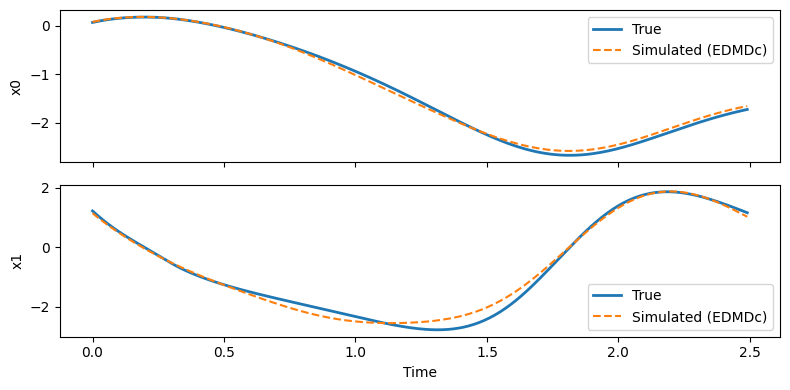

In [14]:
idx = 10
n_ss = 250

X_true = states_cl[idx, :n_ss]
x0 = X_true[0]

X_sim = pk_edmd.simulate(x0, n_steps=n_ss)

t = t_vec[:X_sim.shape[0]]
n_states = X_true.shape[1]
fig, axs = plt.subplots(n_states, 1, figsize=(8, 2*n_states), sharex=True)

for i in range(n_states):
    axs[i].plot(t, X_true[:, i], label="True", linewidth=2)
    axs[i].plot(t, X_sim[:, i], "--", label="Simulated (EDMDc)")
    axs[i].set_ylabel(f"x{i}")
    axs[i].legend()

axs[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Phase C: Time-to-reach bounds analysis on closed-loop dynamic

**Identify more accurate eigenfunctions**

In [15]:
kAnalysis = KoopmanAnalysis(config_path, pk_edmd, stream=stream)
kAnalysis.listEigVal()
_, valid_idx = kAnalysis.eigFunValidity(states_cl, t_vec, alpha=1, score_threshold=2)

Continuous Eigenvales

 eig_v 0 = -1.030+11.629j
 eig_v 1 = -1.030-11.629j
 eig_v 2 = -0.941+8.589j
 eig_v 3 = -0.941-8.589j
 eig_v 4 = -3.672+6.617j
 eig_v 5 = -3.672-6.617j
 eig_v 6 = -1.003+6.015j
 eig_v 7 = -1.003-6.015j
 eig_v 8 = -1.066+4.890j
 eig_v 9 = -1.066-4.890j
 eig_v 10 = -4.064+1.467j
 eig_v 11 = -4.064-1.467j
 eig_v 12 = -0.423+2.978j
 eig_v 13 = -0.423-2.978j
 eig_v 14 = -1.024+2.374j
 eig_v 15 = -1.024-2.374j
 eig_v 16 = 0.000+0.000j
 eig_v 17 = -1.359+0.174j
 eig_v 18 = -1.359-0.174j
 eig_v 19 = -2.001+1.989j
 eig_v 20 = -2.001-1.989j
Pykoopman Validity Check

Eigenfunction scores based on linearity and invariant error:
[5.49070693e+01 5.49070693e+01 4.73668254e+01 4.73668254e+01
 2.20800524e+01 2.20800524e+01 3.17292142e+01 3.17292142e+01
 2.59787292e+01 2.59787292e+01 2.11376122e+01 2.11376122e+01
 6.14536093e+00 6.14536093e+00 1.48645048e+01 1.48645048e+01
 1.95409457e-10 1.13548200e+01 1.13548200e+01 2.34214450e+01
 2.34214450e+01]

Eigenfunction ranking (best to

**Run time to reach bound algorithm**

In [16]:
def hollow_circle_set(center_v, r_in, r_out):
    return [
        {"type": "level_set",
        "function": f"(x1 - {center[0]})^2 + (x2 - {center[1]})^2 - {r_out}^2",
        "bounds": [(center[0] - r_out, center[0] + r_out), (center[1] - r_out, center[1] + r_out)]},
        {"type": "level_set",
        "function": f"{r_out}^2 - ((x1 - {center[0]})^2 + (x2 - {center[1]})^2)",
        "bounds": [(center[0] - r_out, center[0] + r_out), (center[1] - r_out, center[1] + r_out)]}
    ]

initial_set = [{
    "type": "box",
    "bounds": [[1.68, 1.88],[1.16, 1.36]]
}]
target_set = [{
    "type": "box",
    "bounds": [[-3.0, -2.8],[-0.3, -0.1]]
}]

kAnalysis.timeReachBound(
    valid_ef_idx=np.array([12, 13, 17, 18, 15, 14]), 
    n_samples=1000, 
    initial_sets=initial_set, 
    target_sets=target_set
)

Reach-Time bound Analysis

Status: ('PROBABLY REACHABLE', 1)
Reach-time bounds (time intervals when trajectory is in target set):
  Interval 1: [2.061072, 2.198691]

Process time: 0.129744


([(2.0610717056089114, 2.1986911699951497)], ('PROBABLY REACHABLE', 1))

**Varify the reachability with simulation**

Result of reachability with simulation

All trajectories reach the target set with in time bound [2.090, 2.110]
 Process runtime (sec): 0.435018


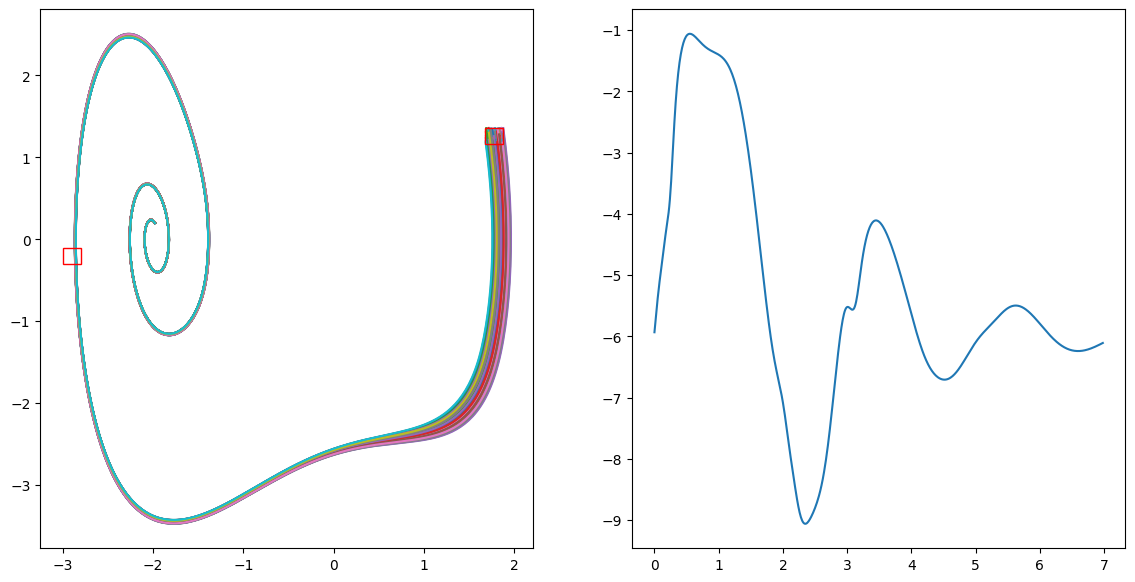

In [17]:
T = 7
dt = 0.01
tested_traj, U = kAnalysis.verifyReachabilityWithSim_c(
    controller=koopman_lqr_u,
    n_samples=100, 
    final_time=T, 
    deltaT=dt,
    initial_set=initial_set,
    target_set=target_set,
    pk_model=pk_edmdc,
    K=K
)

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
a = 0.2
rect1 = patches.Rectangle((1.68, 1.16), a, a, edgecolor='r', facecolor='none', zorder=3)
rect2 = patches.Rectangle((-3.0, -0.3), a, a, edgecolor='r', facecolor='none', zorder=3)
ax[0].add_patch(rect1)
ax[0].add_patch(rect2)

for traj in tested_traj:
    ax[0].plot(traj[:, 0], traj[:, 1])

ax[1].plot(np.arange(0, T-dt, dt), U[0,:-1].squeeze())

plt.show()

### C.1: Avoid unsafe regions

**The unsafe region is a disk that moves along the x1 axis as a function of time h(t), and its radius change with r(t) rate**

In [23]:
def closeLoopSimulation(kmt, controller, x_init, T_end, dt, **kwargs):
    t_vec = np.arange(0, T_end, dt)
    n_steps = len(t_vec)

    sim_traj = np.zeros((x_init.shape[0], n_steps, x_init.shape[1]))
    sim_traj[:, 0, :] = x_init
    
    for i in range(1, n_steps):
        x = sim_traj[:, i-1, :]
        u = controller(x, **kwargs)
        sim_traj[:, i, :] = integralRK4(kmt.system.ff, x, u, dt)

    return sim_traj, t_vec

def h(t):
    x1 = 1.5 * np.sin(0.5 * t - np.pi/2) - 2 # colision 
    # x1 = 1.5 * np.sin(0.5 * t - np.pi/2) - 0.5 # no colision
    x2 = np.zeros(t.shape)
    return np.stack([x1, x2], axis=1)

def r(t):
    return 0.05 * np.cos(2 * t) + 0.35

def circle_sets(center_v, radius_v):
    circle_sets = []
    for center, r in zip(center_v, radius_v):
        circle_sets.append({
            "type": "level_set",
            "function": f"(x1 - {center[0]})^2 + (x2 - {center[1]})^2 - {r}^2",
            "bounds": [(center[0] - r, center[0] + r), (center[1] - r, center[1] + r)]
        })
        
    return circle_sets

#### Animate the collision using simulated trajetories

In [19]:
def animate(sim_traj, h, r, dt, trail_length=None):
    """trail_length: how many previous points to show (0 = full trail)"""
    n_samples, n_steps, _ = sim_traj.shape
    t_vec = np.arange(n_steps) * dt
    
    # --- trajectories animation configs 
    x = sim_traj[:, :, 0]
    y = sim_traj[:, :, 1]
    
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_aspect('equal')

    ax.set_xlim(-5, 3)
    ax.set_ylim(-5, 3)

    # One Line2D per trajectory
    lines = [ax.plot([], [], lw=2)[0] for _ in range(n_samples)]

    time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)

    # --- trajectories animation configs 
    h_vec = h(t_vec)
    r_vec = r(t_vec)

    circle = patches.Circle(h_vec[0], radius=abs(r_vec[0]), ec="r", linewidth=2, fill=False)
    ax.add_patch(circle)

    # --- initialize the animation
    def init():
        for line in lines:
            line.set_data([], [])
            
        circle.center = h_vec[0]
        circle.radius = abs(r_vec[0])
        time_text.set_text('')
        
        return lines + [time_text, circle]
        
    # --- update the animatation
    def update(frame):
        for i, line in enumerate(lines):
            if trail_length is None:
                line.set_data(x[i, :frame+1], y[i, :frame+1])
            else:
                start = max(0, frame - trail_length)
                line.set_data(x[i, start:frame+1], y[i, start:frame+1])

        circle.center = h_vec[frame]
        circle.radius = abs(r_vec[frame])
        time_text.set_text(f"t = {frame * dt:.2f} s")

        return lines + [time_text, circle]
    
    ani = FuncAnimation(
        fig,
        update,
        frames=n_steps,
        init_func=init,
        interval=dt * 3000,
        blit=True
    )

    plt.show()

### Does the system with this policy reach the target set without entering unsafe region?

In [22]:
x_init = np.array([[1.78, 1.26]])
T = 4
r2 = 0.15

sim_traj, _ = closeLoopSimulation(kmt, koopman_lqr_u, x_init, T, 0.01, K=K, pk_model=pk_edmdc)
init_set = circle_sets(x_init, np.array([r2]))

t_vec =  np.arange(0, T, 0.1)
h_vec = h(t_vec)
r_vec = r(t_vec)

unsafe_sets = circle_sets(h_vec, r_vec)

time_intervals_list = []
status_map = np.ones(len(unsafe_sets)) # one reachable, zero unreachable
for i, unsafe_set in enumerate(unsafe_sets):
    time_intervals, status =kAnalysis.timeReachBound(
        valid_ef_idx=np.array([12, 13, 17, 18, 15, 14]), 
        n_samples=100, 
        initial_sets=init_set, 
        target_sets=[unsafe_set],
        stream_off=True
    )
    time_intervals_list.append(time_intervals)
    if status[0] == "UNREACHABLE":
        status_map[i] = 0

colision_risk_idx = []
for i in np.where(status_map > 0)[0]:
    t_i = t_vec[i]
    for t_min, t_max in time_intervals_list[i]:
        if t_i >= t_min and t_i <= t_max:
            colision_risk_idx.append(i)
            break
            
print(status_map)
print(colision_risk_idx)


[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[]
